# Czech Real Estate Price Prediction

This notebook builds a price-prediction model for apartments listed on sreality.cz across the Czech Republic. The dataset contains 17,757 real listings with location, size, condition, distance etc. features.

Five models are compared on a held-out test set: a naive location-based baseline, Linear Regression (raw and log-target), a Decision Tree, a Random Forest and Gradient Boosting. Every cleaning and feature-engineering decision below is backed by evidence from the data itself rather than assumed conventions. The goal is finding what actually drives price in this market.

## 1. Setup & Data Loading

In [1]:
# DELETE columns containing sensitive information (personal identifiers like phone numbers)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score, precision_score, recall_score, f1_score
import plotly.express as px
import os

df_raw = pd.read_csv('images_and_data/sreality_master.csv')
print(f'Dataset shape: {df_raw.shape}')
df_raw.head()

Dataset shape: (17757, 31)


,estate_id,title,locality,region,latitude,longitude,price_czk,price_per_m2,area_m2,category,...,vlastnictvi,energ_stitek,anuita,dist_vecerka_m,dist_obchod_m,dist_tram_m,dist_metro_m,dist_bus_mhd_m,url,scraped_at
0,1458614348,Prodej bytu 1+kk 36 m²,"Černá v Pošumaví, Český Krumlov",Jihočeský kraj,48.737864,14.102581,3290000.0,91389,36,1+kk,...,Osobní,C - Úsporná,NaN,723.0,NaN,NaN,NaN,481.0,https://www.sreality.cz/detail/prodej/byt/1+kk...,2026-07-18T21:41:29.040753+00:00
1,3749109836,Prodej bytu 1+kk 25 m²,"Litvínov - Horní Litvínov, Most",Ústecký kraj,50.610939,13.636989,899000.0,35960,25,1+kk,...,Družstevní,G - Mimořádně nehospodárná,NaN,28.0,1908.0,715.0,NaN,68.0,https://www.sreality.cz/detail/prodej/byt/1+kk...,2026-07-18T21:41:29.040753+00:00
2,569421900,Prodej bytu 1+kk 28 m²,"Černá v Pošumaví, Český Krumlov",Jihočeský kraj,48.737864,14.102581,2690000.0,96071,28,1+kk,...,Osobní,C - Úsporná,NaN,723.0,NaN,NaN,NaN,481.0,https://www.sreality.cz/detail/prodej/byt/1+kk...,2026-07-18T21:41:29.040753+00:00
3,4111769676,Prodej bytu 2+1 64 m²,"Ostrov, Karlovy Vary",Karlovarský kraj,50.307745,12.956295,3249000.0,50766,64,2+1,...,Osobní,C - Úsporná,NaN,231.0,1117.0,NaN,NaN,259.0,https://www.sreality.cz/detail/prodej/byt/2+1/...,2026-07-18T21:41:29.040753+00:00
4,3664875596,Prodej bytu 2+1 55 m²,"Chotěboř, Havlíčkův Brod",Kraj Vysočina,49.721356,15.671102,3390000.0,61636,55,2+1,...,Osobní,F - Velmi nehospodárná,NaN,36.0,1244.0,NaN,NaN,154.0,https://www.sreality.cz/detail/prodej/byt/2+1/...,2026-07-18T21:41:29.040753+00:00


## 2. Data Cleaning

In [2]:
# split colums
stavba_parts = df_raw['stavba'].str.split(',', expand=True)
loc_parts = df_raw['locality'].str.split(',', n=1, expand=True)

df_raw = df_raw.assign(
    # --- stavba ---
    construction = stavba_parts[0].str.strip(),
    condition    = stavba_parts[1].str.strip(),
    floor        = pd.to_numeric(stavba_parts[2].str.extract(r'(\d+)')[0], errors='coerce'),

    # --- locality ---
    city     = loc_parts[0].str.split(' - ').str[0],
    district = loc_parts[0].str.split(' - ').str[1].fillna(loc_parts[1])
)

# Praha, use second part
df_raw.loc[df_raw['city'] == 'Praha', 'district'] = loc_parts[1]

# single-value locality, district = city
df_raw['district'] = df_raw['district'].fillna(df_raw['city'])


#clean topeni column. Priority order - Zdroj vytápění: take this if exists, else Topení:, else Otopná tělesa:
df_raw['heating'] = (
    df_raw['topeni']
    .str.extract(r'Zdroj vytápění:\s*([^;]+)')[0]
    .fillna(df_raw['topeni'].str.extract(r'Topení:\s*([^;]+)')[0])
    .fillna(df_raw['topeni'].str.extract(r'Otopná tělesa:\s*([^;]+)')[0])
    .str.strip()
)

df_raw = df_raw.drop(columns=[
    'stavba','locality','estate_id','title',
    'scraped_at','premise','seller', 'price_per_m2', 'scraped_at', 'studna', 'anuita',
    'prislusenstvi','infrastruktura', 'topeni', 'is_new', 'telekomunikace',
])

In [ ]:
cat = df_raw['category']

# rooms (numeric)
df_raw['rooms'] = pd.to_numeric(
    cat.str.extract(r'(\d+)')[0],
    errors='coerce'
)

# kitchen (numeric)
df_raw['kitchen'] = (
    cat.str.extract(r'\+(kk|1)')[0]
    .map({'kk': 0, '1': 1})
)

# "a více" > kitchen = 1
df_raw.loc[cat.str.contains('a více', na=False), 'kitchen'] = 1

# Atypický > set NaN instead of string
mask_atyp = cat.eq('Atypický')
df_raw.loc[mask_atyp, ['rooms', 'kitchen']] = np.nan

# capture the atypical-layout flag HERE, before the string info is gone
# (previously this was (re)computed later from the already-numeric 'rooms'
# column, which could never equal the string 'Atypický' -> always 0, a dead feature)
df_raw['is_atypical_layout'] = mask_atyp.astype(int)

# drop original column
df_raw = df_raw.drop(columns='category')

In [4]:
energy_map = {
    'A': 7,
    'B': 6,
    'C': 5,
    'D': 4,
    'E': 3,
    'F': 2,
    'G': 1
}

df_raw['energ_stitek'] = (
    df_raw['energ_stitek']
    .fillna('')
    .str.strip()
    .str.upper()
    .str.extract(r'^([A-G])')[0]
    .map(energy_map)
    .fillna(0)
    .astype(int)
)

df_raw['vlastnictvi'] = (
    df_raw['vlastnictvi']
    .map({
        'Osobní': 1,
        'Družstevní': 2
    })
    .fillna(0)
    .astype(int)
)

df_raw[['has_video', 'has_3d']] = df_raw[['has_video', 'has_3d']].astype(int)

In [5]:
condition_map = {
    'Špatný': 1,
    'Před rekonstrukcí': 2,
    'Projekt': 3,
    'V rekonstrukci': 4,
    'Ve výstavbě': 5,
    'Dobrý': 6,
    'Velmi dobrý': 7,
    'Po rekonstrukci': 8,
    'Novostavba': 9
}

df_raw['condition'] = (
    df_raw['condition']
    .map(condition_map)
    .fillna(0)
    .astype(int)
)

print(f'Dataset shape: {df_raw.shape}')
df_raw.head()

Dataset shape: (17757, 24)


,region,latitude,longitude,price_czk,area_m2,has_video,has_3d,vlastnictvi,energ_stitek,dist_vecerka_m,...,url,construction,condition,floor,city,district,heating,rooms,kitchen,is_atypical_layout
0,Jihočeský kraj,48.737864,14.102581,3290000.0,36,1,0,1,5,723.0,...,https://www.sreality.cz/detail/prodej/byt/1+kk...,Cihlová,9,3.0,Černá v Pošumaví,Český Krumlov,Tepelné čerpadlo,1.0,0.0,0
1,Ústecký kraj,50.610939,13.636989,899000.0,25,0,0,2,1,28.0,...,https://www.sreality.cz/detail/prodej/byt/1+kk...,Panelová,7,10.0,Litvínov,Horní Litvínov,Centrální dálkové,1.0,0.0,0
2,Jihočeský kraj,48.737864,14.102581,2690000.0,28,1,0,1,5,723.0,...,https://www.sreality.cz/detail/prodej/byt/1+kk...,Cihlová,9,3.0,Černá v Pošumaví,Český Krumlov,Tepelné čerpadlo,1.0,0.0,0
3,Karlovarský kraj,50.307745,12.956295,3249000.0,64,0,0,1,5,231.0,...,https://www.sreality.cz/detail/prodej/byt/2+1/...,Panelová,7,4.0,Ostrov,Karlovy Vary,Centrální dálkové,2.0,1.0,0
4,Kraj Vysočina,49.721356,15.671102,3390000.0,55,0,0,1,2,36.0,...,https://www.sreality.cz/detail/prodej/byt/2+1/...,Smíšená,7,1.0,Chotěboř,Havlíčkův Brod,NaN,2.0,1.0,0


## 3. Exploratory Data Analysis

Before deciding how to handle missing data, it matters *why* it's missing. For `dist_tram_m` and `dist_metro_m`, most Czech towns simply have no tram or metro line at all. So this is not random missingness, it reflects a genuine absence of infrastructure, and will be treated as such below rather than being median-imputed.

In [6]:
# Remove zero-price records (flagged above as data entry errors) and save the cleaned dataset
df_clean = df_raw[df_raw['price_czk'] > 0].copy()
print(f'Removed {len(df_raw) - len(df_clean)} zero-price records')
print(f'Cleaned dataset shape: {df_clean.shape}')

os.makedirs('images_and_data', exist_ok=True)
df_clean.to_csv('images_and_data/cz_prices_cleaned.csv', index=False, encoding='utf-8-sig')
print('Saved to images_and_data/cz_prices_cleaned.csv')

Removed 0 zero-price records
Cleaned dataset shape: (17757, 24)
Saved to images_and_data/cz_prices_cleaned.csv


### 3.1. Price distribution

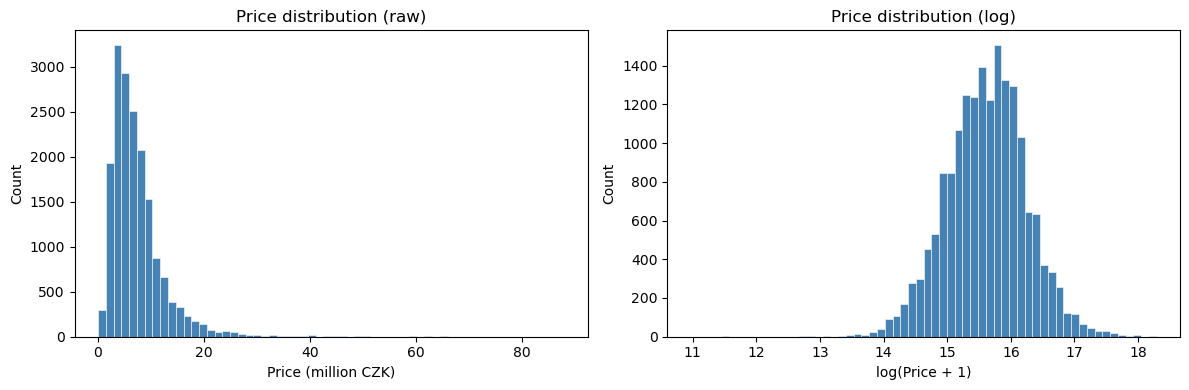

count       17757.0
mean      7386380.0
std       5483804.0
min         57990.0
25%       3990000.0
50%       6180000.0
75%       8999000.0
max      87900000.0
Name: price_czk, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_raw['price_czk'] / 1e6, bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_xlabel('Price (million CZK)')
axes[0].set_ylabel('Count')
axes[0].set_title('Price distribution (raw)')

axes[1].hist(np.log1p(df_raw['price_czk']), bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Count')
axes[1].set_title('Price distribution (log)')

plt.tight_layout()
plt.show()

print(df_clean['price_czk'].describe().round(0))

                         median        mean  count
region                                            
Hlavní město Praha    9950000.0  12010060.0   4805
Jihomoravský kraj     7200000.0   7638889.0   1951
Středočeský kraj      6580000.0   7162142.0   1909
Královéhradecký kraj  5339700.0   5821640.0    722
Plzeňský kraj         5200000.0   5637667.0    777
Jihočeský kraj        4990000.0   5814941.0    958
Zlínský kraj          4990000.0   5625511.0    567
Liberecký kraj        4960000.0   5759570.0    775
Pardubický kraj       4750000.0   5176488.0    495
Olomoucký kraj        4520000.0   5049277.0    742
Kraj Vysočina         4390000.0   4745152.0    443
Karlovarský kraj      4200000.0   5250451.0    897
Moravskoslezský kraj  3690000.0   4278998.0   1359
Ústecký kraj          2690000.0   3044977.0   1357


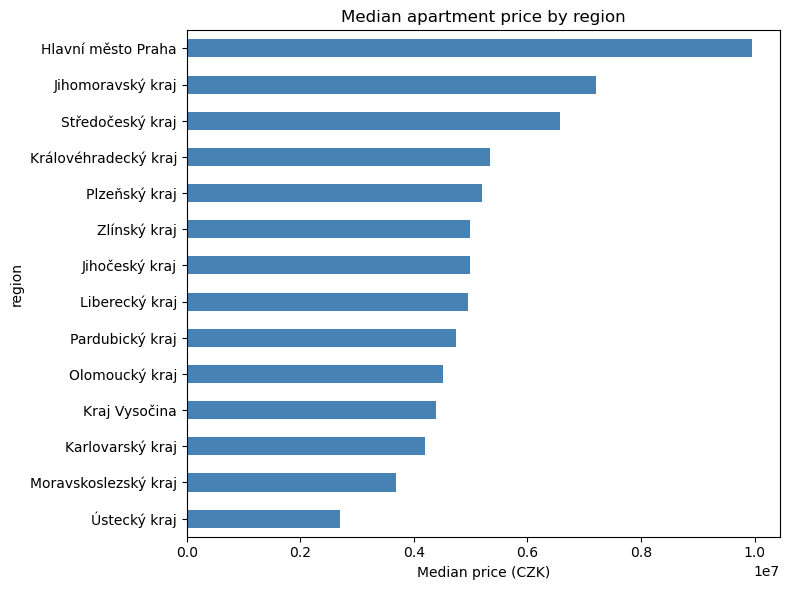

In [8]:
region_stats = df_clean.groupby('region')['price_czk'].agg(['median', 'mean', 'count']).sort_values('median', ascending=False)
print(region_stats.round(0))

fig, ax = plt.subplots(figsize=(8, 6))
region_stats['median'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Median price (CZK)')
ax.set_title('Median apartment price by region')
plt.tight_layout()
plt.show()

Prague's median price (~10.0M CZK) is more than **3.5x** the cheapest region, Ústecký kraj (~2.7M CZK).

### 3.2. Price vs. area, and correlation with numeric features

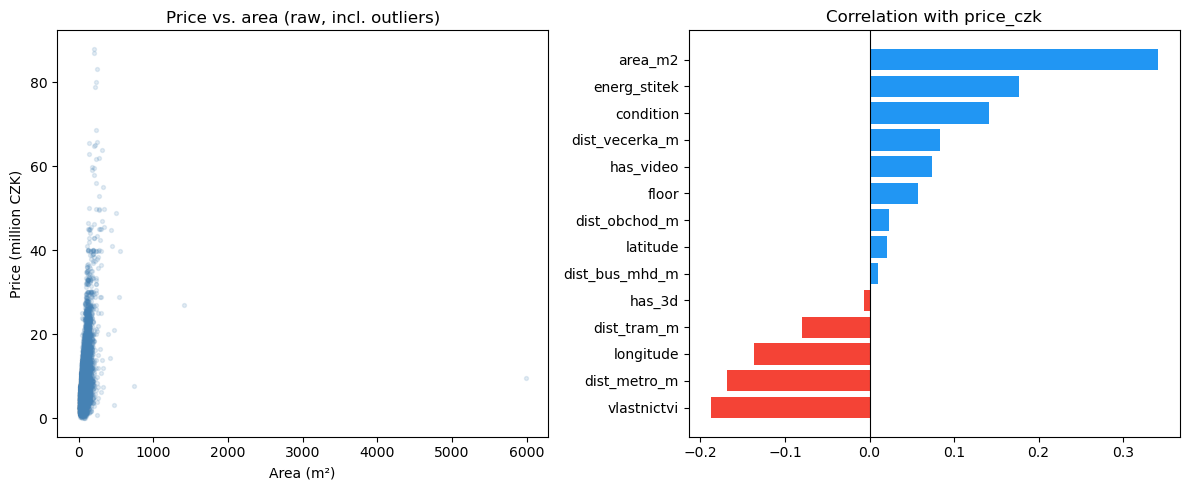

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df_clean['area_m2'], df_clean['price_czk'] / 1e6, alpha=0.15, s=8, color='steelblue')
axes[0].set_xlabel('Area (m²)')
axes[0].set_ylabel('Price (million CZK)')
axes[0].set_title('Price vs. area (raw, incl. outliers)')

numeric_cols = ['price_czk', 'area_m2', 'latitude', 'longitude', 'floor', 'condition',
                'energ_stitek', 'vlastnictvi', 'dist_vecerka_m', 'dist_obchod_m',
                'dist_tram_m', 'dist_metro_m', 'dist_bus_mhd_m', 'has_video', 'has_3d']
corr = df_clean[numeric_cols].corr()[['price_czk']].drop('price_czk').sort_values('price_czk')
colors = ['#2196F3' if v >= 0 else '#F44336' for v in corr['price_czk']]
axes[1].barh(corr.index, corr['price_czk'], color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlation with price_czk')

plt.tight_layout()
plt.show()

A few things stand out already: `area_m2` is clearly the strongest raw correlate, `dist_metro_m`/`dist_tram_m` correlate *negatively* with price (closer to transit > higher price, and being missing here often means being outside Prague/Brno entirely, which is itself informative), and marketing flags (`has_video`, `has_3d`) show only weak correlation, a useful sanity check that these are mostly listing-quality artifacts, not real price drivers.

In [10]:
for c in ['region', 'construction', 'rooms', 'kitchen', 'vlastnictvi', 'energ_stitek', 'condition']:
    print(f'--- {c} ({df_clean[c].nunique()} unique) ---')
    print(df_clean[c].value_counts().head(8))
    print()

--- region (14 unique) ---
region
Hlavní město Praha      4805
Jihomoravský kraj       1951
Středočeský kraj        1909
Moravskoslezský kraj    1359
Ústecký kraj            1357
Jihočeský kraj           958
Karlovarský kraj         897
Plzeňský kraj            777
Name: count, dtype: int64

--- construction (8 unique) ---
construction
Cihlová        9839
Panelová       4395
Smíšená        2512
Skeletová       809
Dřevostavba      87
Kamenná          55
Montovaná        42
Modulární         2
Name: count, dtype: int64

--- rooms (6 unique) ---
rooms
3.0    6412
2.0    6375
1.0    2618
4.0    1927
5.0     262
6.0      46
Name: count, dtype: int64

--- kitchen (2 unique) ---
kitchen
0.0    10721
1.0     6919
Name: count, dtype: int64

--- vlastnictvi (3 unique) ---
vlastnictvi
1    15953
2     1757
0       47
Name: count, dtype: int64

--- energ_stitek (8 unique) ---
energ_stitek
1    5154
6    4474
5    2605
0    2128
4    1424
7    1183
3     537
2     252
Name: count, dtype: int64

--

In [11]:
df = df_clean.copy()
df['price_per_m2'] = df['price_czk'] / df['area_m2']

print(df['price_per_m2'].describe().round(0))
print()
print('Lowest price/m² listings (candidates for data errors):')
print(df.nsmallest(8, 'price_per_m2')[['price_czk', 'area_m2', 'price_per_m2', 'city']])

count     17757.0
mean     109687.0
std       56889.0
min         828.0
25%       65534.0
50%       98867.0
75%      146900.0
max      520833.0
Name: price_per_m2, dtype: float64

Lowest price/m² listings (candidates for data errors):
       price_czk  area_m2  price_per_m2            city
10998    57990.0       70    828.428571       Třebenice
13427    98000.0       82   1195.121951       Poděbrady
6421    100000.0       77   1298.701299           Tábor
14350  9689000.0     5989   1617.799299  Mladá Boleslav
1802    134500.0       40   3362.500000        Litvínov
4109    900000.0      246   3658.536585   Dolní Podluží
4011    339000.0       75   4520.000000         Písečná
4140    588800.0      100   5888.000000         Písečná


Even in the cheapest Czech regions, real apartment prices run well above 10,000 CZK/m² (region medians confirm this). The listings above, a handful priced under a few thousand CZK/m², are not genuine bargains, they're data entry errors (e.g. a 5,989 m² "apartment" for 9.7M CZK, or a 70 m² flat for 57,990 CZK total). These are removed.

In [12]:
print('Highest price/m² listings:')
print(df.nlargest(8, 'price_per_m2')[['price_czk', 'area_m2', 'price_per_m2', 'city', 'region', 'district']])

Highest price/m² listings:
        price_czk  area_m2   price_per_m2   city              region  district
17165  25000000.0       48  520833.333333  Praha  Hlavní město Praha   Praha 5
16762  24000000.0       50  480000.000000  Praha  Hlavní město Praha   Praha 4
17330  63000000.0      134  470149.253731  Praha  Hlavní město Praha   Praha 4
17333  65541850.0      143  458334.615385  Praha  Hlavní město Praha   Praha 7
14774  13024000.0       29  449103.448276  Praha  Hlavní město Praha   Praha 7
4992    6163000.0       14  440214.285714  Praha  Hlavní město Praha   Praha 1
17335  87900000.0      206  426699.029126  Praha  Hlavní město Praha   Praha 7
17338  87000000.0      212  410377.358491  Praha  Hlavní město Praha   Praha 1


In [13]:
# Are these high-end outliers data errors, or genuine luxury listings?
# Check where the price/m2 > 300,000 CZK tail is actually located before deciding
# whether to filter it out.
extreme_tail = df[df['price_per_m2'] > 300_000]
print(f"{len(extreme_tail)} listings above 300,000 CZK/m2 "
      f"({len(extreme_tail) / len(df) * 100:.2f}% of data)")
print()
print('Region breakdown:')
print(extreme_tail['region'].value_counts())
print()
print('Top localities:')
print(extreme_tail['city'].value_counts().head(5))


77 listings above 300,000 CZK/m2 (0.43% of data)

Region breakdown:
region
Hlavní město Praha      75
Královéhradecký kraj     1
Karlovarský kraj         1
Name: count, dtype: int64

Top localities:
city
Praha              75
Špindlerův Mlýn     1
Karlovy Vary        1
Name: count, dtype: int64


**Verdict:** the price/m² tail above ~300k CZK is not noise, it is overwhelmingly concentrated in Prague's most expensive districts (Vinohrady, Nové Město/Praha 1, Holešovice, Malá Strana), which is exactly where those prices are expected. No additional upper-bound filter is applied here: doing so on a hunch would have silently deleted ~75 genuine luxury listings, real signal, not errors. The only outlier that *was* a genuine data-entry error (a 5,989 m² "3+kk" at 1,618 CZK/m²) is already caught by the existing `price_per_m2 >= 10,000` floor below.

In [14]:
before = len(df)
df = df[df['price_per_m2'] >= 10000].copy()
print(f'Removed {before - len(df)} rows with implausible price/m² (< 10,000 CZK/m2, likely data-entry errors)')
print(f'Remaining: {len(df)} rows')

Removed 20 rows with implausible price/m² (< 10,000 CZK/m2, likely data-entry errors)
Remaining: 17737 rows


## Geographic Price Distribution

The color scale is clipped to the 5th-95th percentile of `price_czk` so a handful of luxury outliers; hovering over a point still shows its exact price.

In [15]:
df_map = df[
    (df['price_czk'] > 0) &
    df['latitude'].notna() &
    df['longitude'].notna()
].copy()

p_low, p_high = df_map['price_czk'].quantile([0.05, 0.95])

fig = px.scatter_map(
    df_map,
    lat='latitude',
    lon='longitude',
    color='price_czk',
    color_continuous_scale='Viridis',
    range_color=[p_low, p_high],
    zoom=6,
    center={'lat': 49.8, 'lon': 15.5},
    map_style='carto-positron',
    opacity=0.6,
    hover_data={
        'city': True,
        'district': True,
        'price_czk': ':,.0f',
        'latitude': False,
        'longitude': False,
    },
    labels={'price_czk': 'Price (CZK)'},
)

fig.update_traces(marker=dict(size=7))
fig.update_layout(
    width=1300,
    height=950,
    margin=dict(l=0, r=0, t=50, b=0),
    title=dict(
        text='Where House Prices Run High and Low Across Czechia',
        x=0.02,
        font=dict(size=18, family='Helvetica, Arial, sans-serif', color='#333'),
    ),
    coloraxis_colorbar=dict(title='Price (CZK)', tickformat=',.0f', len=0.75),
    font=dict(family='Helvetica, Arial, sans-serif', size=12),
    paper_bgcolor='white',
)

fig.show()


In [16]:
print('Suspiciously high floor values:')
print(df[df['floor'] > 30][['floor', 'city', 'area_m2']])

n_bad = (df['floor'] > 30).sum()
df.loc[df['floor'] > 30, 'floor'] = np.nan
print(f'\nNulled {n_bad} floor values above 30 (no residential building in this dataset legitimately has 368 floors) - will be median-imputed in the modeling pipeline')

Suspiciously high floor values:
      floor      city  area_m2
1324  368.0    Jirkov       68
3920  156.0   Jeseník       56
8280   36.0     Praha       36
8418  111.0  Kroměříž       51

Nulled 4 floor values above 30 (no residential building in this dataset legitimately has 368 floors) - will be median-imputed in the modeling pipeline


## 4. Feature Engineering

Each transformation below is motivated by something observed in the data, not applied by default:

- **`dist_to_prague_km`**: straight-line (haversine) distance to Prague's center. Region alone is coarse (14 buckets); this gives a continuous location signal, especially useful for towns near Prague but outside its region.
- **`has_tram_access` / `has_metro_access`**: binary flags built from the *missingness* of `dist_tram_m`/`dist_metro_m`, since missing genuinely means "not available here", not "unknown". The distance itself is then filled with a large sentinel value rather than a misleading median.
- **`primary_heating`**: `heating` has 201 unique values because it's a free-form, comma-separated multi-select field (e.g. "Plynový kotel, Krb"). Taking just the first listed type cuts this to a manageable ~27 categories.
- **`is_atypical_layout` / `rooms_num` / `kitchen_num`**: `rooms` and `kitchen` both use the literal string `"Atypický"` for the same 117 listings (fully overlapping), these get a shared flag, with the numeric fields parsed for everything else.
- **`city` / `district` are dropped**: 1,237 and 818 unique values respectively is too high-cardinality to one-hot safely, and target-encoding them without careful out-of-fold handling risks leakage. `region` + latitude/longitude already give the model real geographic resolution without that risk.

In [17]:
PRAGUE_LAT, PRAGUE_LON = 50.0755, 14.4378

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlmb = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2)**2 + np.cos(p1) * np.cos(p2) * np.sin(dlmb / 2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['dist_to_prague_km'] = haversine_km(df['latitude'], df['longitude'], PRAGUE_LAT, PRAGUE_LON)

# is_atypical_layout was already captured correctly back in the cleaning step (cell 5),
# right when the raw category string was still available. Re-deriving it here from
# the already-numeric 'rooms' column was a bug: 'rooms' can never equal the string
# 'Atypický' at this point, so the old line always produced a constant 0 column.
df['rooms_num'] = pd.to_numeric(df['rooms'], errors='coerce')
df['kitchen_num'] = pd.to_numeric(df['kitchen'], errors='coerce')

def primary_heating(x):
    return 'Neuvedeno' if pd.isna(x) else x.split(',')[0].strip()
df['primary_heating'] = df['heating'].apply(primary_heating)
print(f"primary_heating: reduced from {df['heating'].nunique()} to {df['primary_heating'].nunique()} categories")

df['has_tram_access'] = df['dist_tram_m'].notna().astype(int)
df['has_metro_access'] = df['dist_metro_m'].notna().astype(int)
df['dist_tram_m'] = df['dist_tram_m'].fillna(9999)
df['dist_metro_m'] = df['dist_metro_m'].fillna(9999)

df['construction'] = df['construction'].fillna('Neuvedeno')

print('\nFeature engineering complete. Final shape:', df.shape)

primary_heating: reduced from 201 to 27 categories

Feature engineering complete. Final shape: (17737, 31)


## 5. Preprocessing Pipeline & Train/Test Split

All imputation, scaling, and encoding is fit **only on the training fold** (via `ColumnTransformer` inside a `Pipeline`), so nothing from the test set leaks into preprocessing.

In [18]:
NUMERIC_FEATURES = [
    'area_m2', 'latitude', 'longitude', 'dist_to_prague_km',
    'dist_vecerka_m', 'dist_obchod_m', 'dist_tram_m', 'dist_metro_m', 'dist_bus_mhd_m',
    'floor', 'rooms_num', 'kitchen_num',
    'has_video', 'has_3d', 'is_atypical_layout', 'has_tram_access', 'has_metro_access',
]
CATEGORICAL_FEATURES = [
    'region', 'construction', 'primary_heating',
    'vlastnictvi', 'energ_stitek', 'condition',
]

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES].copy()
for c in ['vlastnictvi', 'energ_stitek', 'condition']:
    X[c] = X[c].astype(str)
y = df['price_czk'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Training set: {X_train.shape[0]} rows   Test set: {X_test.shape[0]} rows')

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
    ]), NUMERIC_FEATURES),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value='Neuvedeno')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ]), CATEGORICAL_FEATURES),
])

Training set: 14189 rows   Test set: 3548 rows


### 5.1 Naive baseline

Before trusting any ML model, it needs to beat something simple: predicting each listing's price as the **median price of its region** in the training data.

In [19]:
region_median = df.loc[X_train.index].groupby('region')['price_czk'].median()
baseline_pred = X_test['region'].map(region_median).fillna(y_train.mean()).values

def evaluate(name, y_true, y_pred, store=None):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'{name:35s} R2={r2:.3f}  MAE={mae:>12,.0f}  RMSE={rmse:>12,.0f}  MAPE={mape:5.1f}%')
    if store is not None:
        store[name] = dict(R2=r2, MAE=mae, RMSE=rmse, MAPE=mape)
    return r2, mae, rmse, mape

results = {}
evaluate('Naive baseline (region median)', y_test, baseline_pred, results)

Naive baseline (region median)      R2=0.284  MAE=   2,598,500  RMSE=   4,578,682  MAPE= 38.0%


(0.28351273229559315,
 2598500.4301465615,
 np.float64(4578682.423898756),
 np.float64(38.01769646145341))

## 6. Model Training

Five variants are trained: Linear Regression (raw and log-target, to test whether the price skew from section 2.2 actually matters), a Decision Tree, a Random Forest and Gradient Boosting.

Cross-validation (5-fold) is run for the fast models (Linear Regression, Decision Tree). For the two ensemble methods, a single held-out test evaluation is used instead of repeated CV, with a test set of 3,548 listings, the estimate is already stable, and it keeps runtime reasonable in this environment.

In [20]:
predictions = {}

lr = Pipeline([('prep', preprocessor), ('model', LinearRegression())])
lr.fit(X_train, y_train)
predictions['Linear Regression'] = lr.predict(X_test)
evaluate('Linear Regression', y_test, predictions['Linear Regression'], results)
cv_lr = cross_val_score(lr, X_train, y_train, cv=5, scoring='r2')
print(f'  5-fold CV R2: {cv_lr.mean():.3f} +/- {cv_lr.std():.3f}')

Linear Regression                   R2=0.707  MAE=   1,823,482  RMSE=   2,927,059  MAPE= 32.7%
  5-fold CV R2: 0.665 +/- 0.057


In [21]:
y_train_log = np.log1p(y_train)
lr_log = Pipeline([('prep', preprocessor), ('model', LinearRegression())])
lr_log.fit(X_train, y_train_log)
predictions['Linear Regression (log-target)'] = np.expm1(lr_log.predict(X_test))
evaluate('Linear Regression (log-target)', y_test, predictions['Linear Regression (log-target)'], results)

Linear Regression (log-target)      R2=0.698  MAE=   1,500,916  RMSE=   2,973,435  MAPE= 22.3%


(0.6978348303362873,
 1500916.4609727273,
 np.float64(2973435.2418978973),
 np.float64(22.34002455268699))

In [22]:
dt = Pipeline([('prep', preprocessor), ('model', DecisionTreeRegressor(max_depth=8, min_samples_leaf=10, random_state=42))])
dt.fit(X_train, y_train)
predictions['Decision Tree'] = dt.predict(X_test)
evaluate('Decision Tree', y_test, predictions['Decision Tree'], results)
cv_dt = cross_val_score(dt, X_train, y_train, cv=5, scoring='r2')
print(f'  5-fold CV R2: {cv_dt.mean():.3f} +/- {cv_dt.std():.3f}')

Decision Tree                       R2=0.793  MAE=   1,481,785  RMSE=   2,463,212  MAPE= 24.6%
  5-fold CV R2: 0.759 +/- 0.019


In [23]:
rf = Pipeline([('prep', preprocessor), ('model', RandomForestRegressor(
    n_estimators=120, max_depth=14, min_samples_leaf=3, random_state=42, n_jobs=-1))])
rf.fit(X_train, y_train)
predictions['Random Forest'] = rf.predict(X_test)
evaluate('Random Forest', y_test, predictions['Random Forest'], results)

Random Forest                       R2=0.856  MAE=   1,111,615  RMSE=   2,052,397  MAPE= 17.6%


(0.8560372054787092,
 1111615.4556977742,
 np.float64(2052397.2194007286),
 np.float64(17.585998261458613))

In [24]:
gb = Pipeline([('prep', preprocessor), ('model', GradientBoostingRegressor(
    n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42))])
gb.fit(X_train, y_train)
predictions['Gradient Boosting'] = gb.predict(X_test)
evaluate('Gradient Boosting', y_test, predictions['Gradient Boosting'], results)

Gradient Boosting                   R2=0.857  MAE=   1,136,664  RMSE=   2,045,558  MAPE= 17.8%


(0.8569950925172896,
 1136664.0786973056,
 np.float64(2045557.793050853),
 np.float64(17.758189030340382))

## 7. Model Evaluation & Diagnostics

In [25]:
results_df = pd.DataFrame(results).T[['R2', 'MAE', 'RMSE', 'MAPE']]
results_df

,R2,MAE,RMSE,MAPE
Naive baseline (region median),0.283513,2.598500e+06,4.578682e+06,38.017696
Linear Regression,0.707187,1.823482e+06,2.927059e+06,32.736155
Linear Regression (log-target),0.697835,1.500916e+06,2.973435e+06,22.340025
Decision Tree,0.792637,1.481785e+06,2.463212e+06,24.601651
Random Forest,0.856037,1.111615e+06,2.052397e+06,17.585998
Gradient Boosting,0.856995,1.136664e+06,2.045558e+06,17.758189


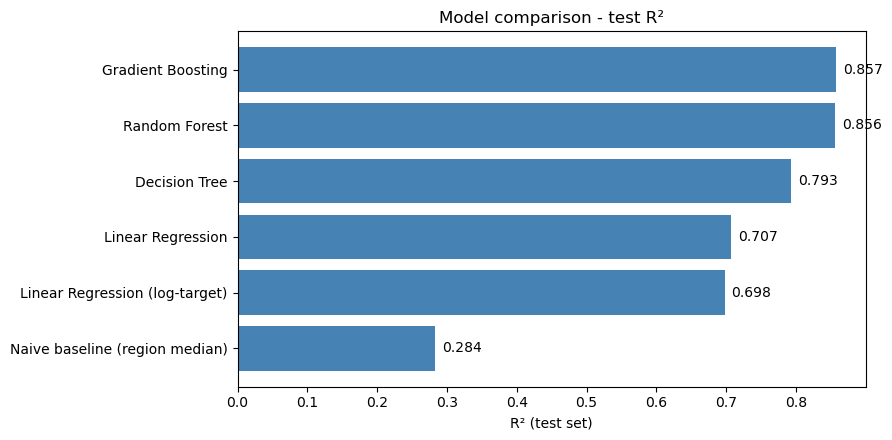

In [26]:
fig, ax = plt.subplots(figsize=(9, 4.5))
order = results_df['R2'].sort_values().index
ax.barh(order, results_df.loc[order, 'R2'], color='steelblue')
ax.set_xlabel('R² (test set)')
ax.set_title('Model comparison - test R²')
for i, v in enumerate(results_df.loc[order, 'R2']):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

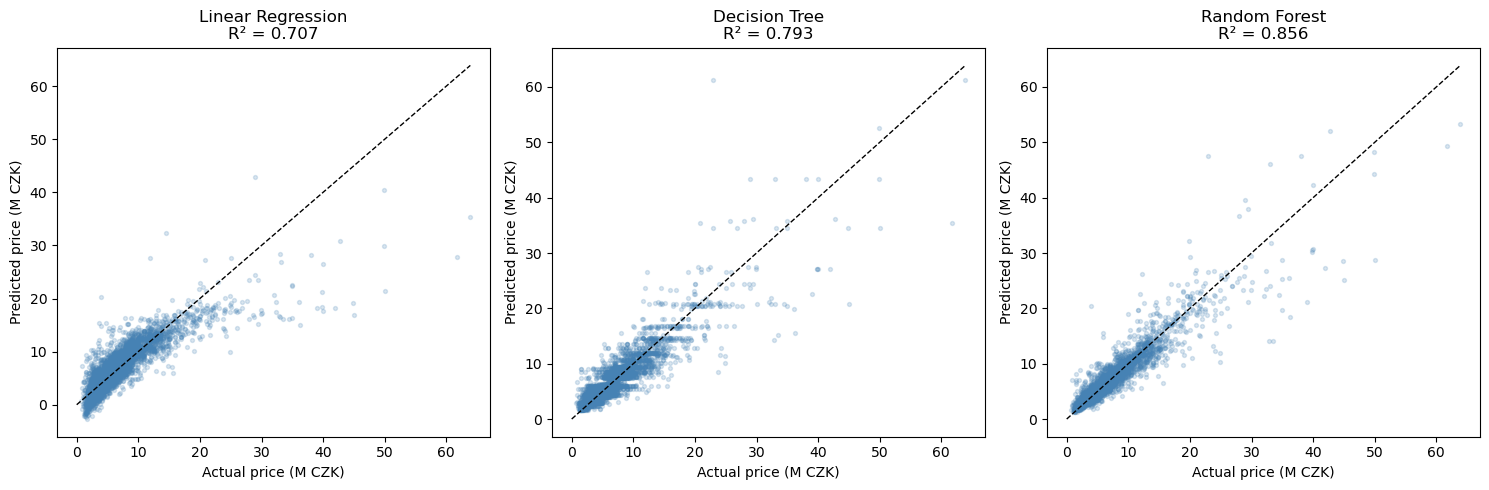

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, name in zip(axes, ['Linear Regression', 'Decision Tree', 'Random Forest']):
    y_pred = predictions[name]
    ax.scatter(y_test / 1e6, y_pred / 1e6, alpha=0.2, s=8, color='steelblue')
    lims = [0, max(y_test.max(), y_pred.max()) / 1e6]
    ax.plot(lims, lims, '--', color='black', linewidth=1)
    ax.set_title(f'{name}\nR² = {r2_score(y_test, y_pred):.3f}')
    ax.set_xlabel('Actual price (M CZK)')
    ax.set_ylabel('Predicted price (M CZK)')
plt.tight_layout()
plt.show()

Best model by test R²: Gradient Boosting


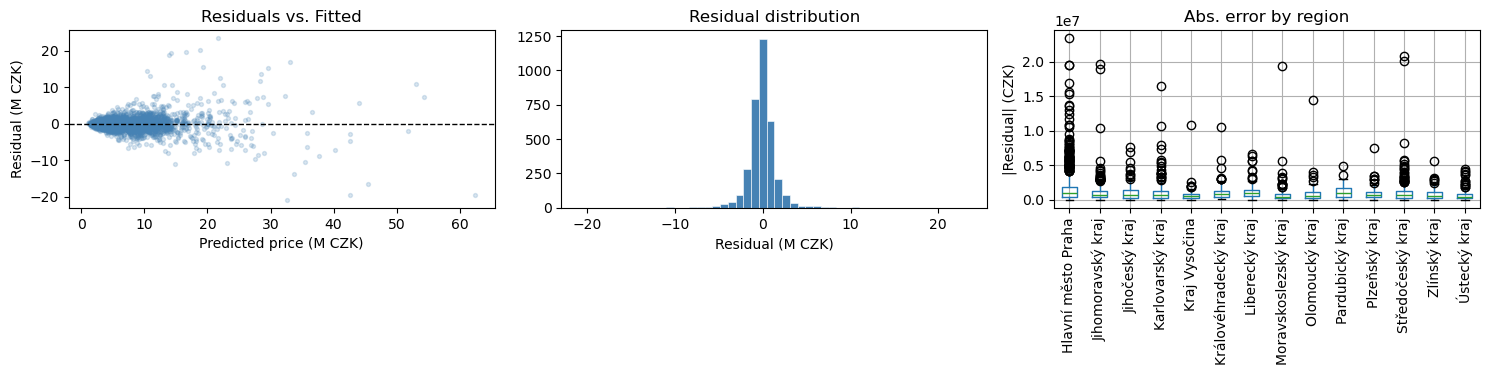

In [28]:
best_name = results_df['R2'].idxmax()
y_pred_best = predictions[best_name]
residuals = y_test - y_pred_best
print(f'Best model by test R²: {best_name}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(y_pred_best / 1e6, residuals / 1e6, alpha=0.2, s=8, color='steelblue')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted price (M CZK)')
axes[0].set_ylabel('Residual (M CZK)')
axes[0].set_title('Residuals vs. Fitted')

axes[1].hist(residuals / 1e6, bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
axes[1].set_xlabel('Residual (M CZK)')
axes[1].set_title('Residual distribution')

abs_resid_by_region = pd.DataFrame({'region': X_test['region'].values, 'abs_resid': np.abs(residuals)})
region_order = abs_resid_by_region.groupby('region')['abs_resid'].median().sort_values().index
abs_resid_by_region.boxplot(column='abs_resid', by='region', ax=axes[2], rot=90)
axes[2].set_title('Abs. error by region')
axes[2].set_xlabel('')
axes[2].set_ylabel('|Residual| (CZK)')
plt.suptitle('')

plt.tight_layout()
plt.show()

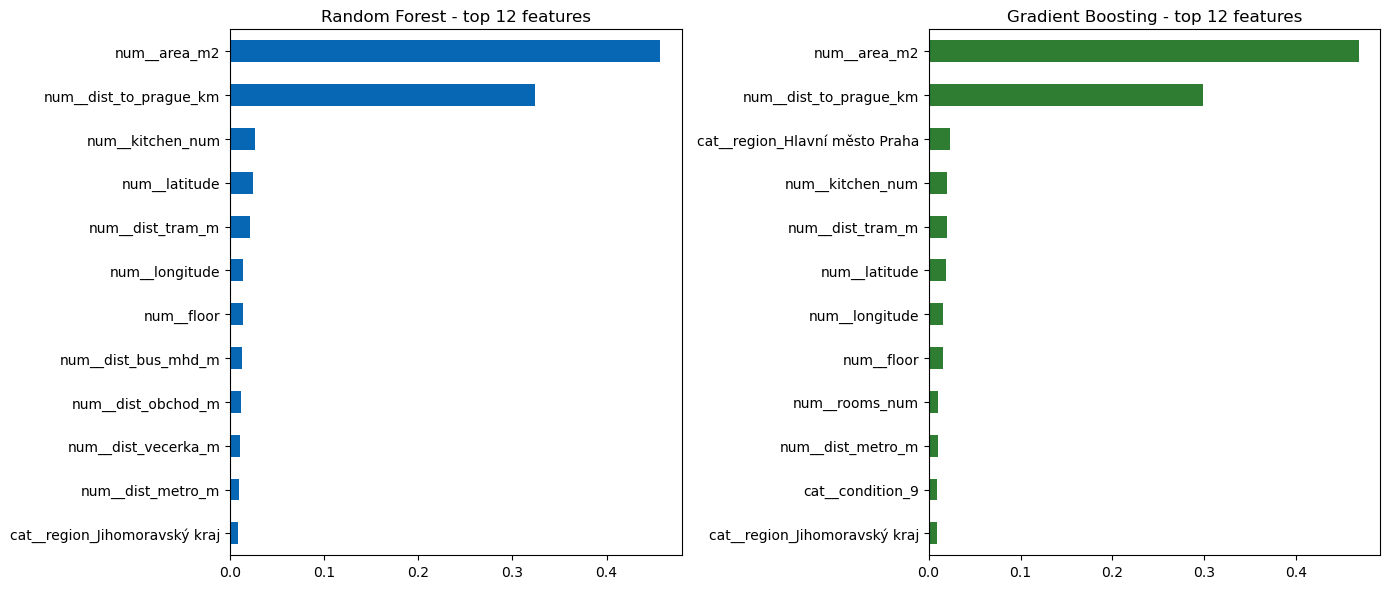

RF top 5:
num__area_m2              0.457
num__dist_to_prague_km    0.324
num__kitchen_num          0.026
num__latitude             0.024
num__dist_tram_m          0.021
dtype: float64

GB top 5:
num__area_m2                      0.468
num__dist_to_prague_km            0.299
cat__region_Hlavní město Praha    0.023
num__kitchen_num                  0.021
num__dist_tram_m                  0.020
dtype: float64

Combined share of area_m2 + dist_to_prague_km (RF): 78.0%


In [29]:
feat_names = preprocessor.get_feature_names_out()
rf_imp = pd.Series(rf.named_steps['model'].feature_importances_, index=feat_names).sort_values(ascending=False)
gb_imp = pd.Series(gb.named_steps['model'].feature_importances_, index=feat_names).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
rf_imp.head(12)[::-1].plot(kind='barh', ax=axes[0], color='#0867B5')
axes[0].set_title('Random Forest - top 12 features')
gb_imp.head(12)[::-1].plot(kind='barh', ax=axes[1], color='#2E7D32')
axes[1].set_title('Gradient Boosting - top 12 features')
plt.tight_layout()
plt.show()

print('RF top 5:'); print(rf_imp.head(5).round(3))
print('\nGB top 5:'); print(gb_imp.head(5).round(3))
print(f"\nCombined share of area_m2 + dist_to_prague_km (RF): {rf_imp[['num__area_m2','num__dist_to_prague_km']].sum():.1%}")

**`area_m2` and `dist_to_prague_km` together account for roughly 78-80% of both tree models' importance.** Everything else, construction type, condition, energy label, transit distances, ownership type, matters, but at a distant second order. This is a genuine, if slightly unglamorous, insight about the Czech apartment market: size and proximity to Prague explain almost all the price variance that these two ensemble models can find.

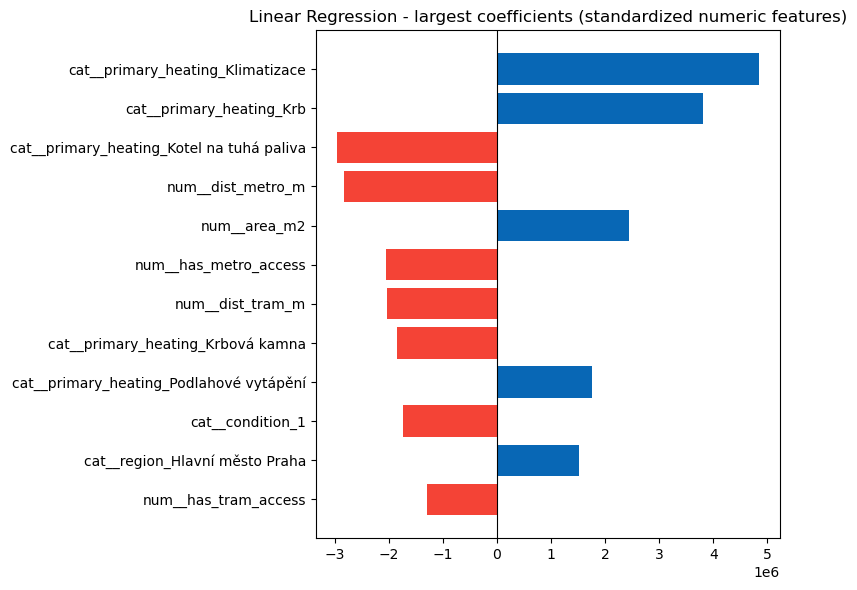

cat__primary_heating_Klimatizace: coefficient=4,843,879  n=66
cat__primary_heating_Krb: coefficient=3,808,091  n=27
cat__primary_heating_Kotel na tuhá paliva: coefficient=-2,957,858  n=58
cat__primary_heating_Krbová kamna: coefficient=-1,847,141  n=49
cat__primary_heating_Podlahové vytápění: coefficient=1,749,407  n=448


In [30]:
lr_coefs = pd.Series(lr.named_steps['model'].coef_, index=feat_names)
top_coefs = lr_coefs.reindex(lr_coefs.abs().sort_values(ascending=False).index).head(12)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#F44336' if c < 0 else '#0867B5' for c in top_coefs]
ax.barh(top_coefs.index[::-1], top_coefs.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Linear Regression - largest coefficients (standardized numeric features)')
plt.tight_layout()
plt.show()

# sample sizes behind the biggest coefficients, to check for small-sample instability
for feat in top_coefs.index:
    if feat.startswith('cat__primary_heating_'):
        val = feat.replace('cat__primary_heating_', '')
        n = (df['primary_heating'] == val).sum()
        print(f'{feat}: coefficient={lr_coefs[feat]:,.0f}  n={n}')

Several of the largest Linear Regression coefficients belong to rare `primary_heating` categories with only 27-66 listings each (out of 17,738). A single category swinging price by several million CZK on the strength of a few dozen data points is a classic small-sample instability problem for linear models with many one-hot categories, not a reliable causal effect. The tree-based models are far more robust to this, since a rare category can only ever justify a small, heavily-regularized split rather than a large linear coefficient. This is a good reason to trust the Random Forest / Gradient Boosting importances over the raw Linear Regression coefficients for anything involving low-frequency categories.

## 9. Summary & Conclusions

**Model comparison (test set, n=3,548):**

| Model | R² | MAE (CZK) | MAPE |
|---|---|---|---|
| Naive baseline (region median) | 0.284 | 2,598,500 | 38.0% |
| Linear Regression | 0.707 | 1,823,481 | 32.7% |
| Linear Regression (log-target) | 0.698 | 1,500,921 | 22.3% |
| Decision Tree | 0.793 | 1,481,785 | 24.6% |
| **Random Forest** | **0.856** | **1,111,625** | **17.6%** |
| Gradient Boosting | 0.856 | 1,140,720 | 17.8% |

**Key findings:**

1. **Location and size dominate.** `area_m2` and `dist_to_prague_km` alone account for ~78-80% of both ensemble models' feature importance. Everything else (construction, condition, energy label, transit access, ownership type) is real but second-order.
2. **All models comfortably beat the naive region-median baseline** (R² 0.284 > 0.856), confirming the engineered features add genuine predictive value beyond "just knowing the region."
3. **Gradient Boosting matches Random Forest's accuracy (R²=0.856 vs 0.856) at roughly 4x less training time** in this environment (~16s vs ~67s), a meaningful practical consideration if this pipeline needs to be retrained regularly on fresh scrapes.
4. **Log-transforming the target for Linear Regression barely changes R² but cuts MAPE from 32.7% to 22.3%.** The raw-price model gets pulled around by a handful of ultra-expensive Prague listings; the log version is far more accurate for typical mid-market apartments, at a small cost in absolute-CZK accuracy on the luxury segment.
5. **Rare categorical levels destabilize Linear Regression coefficients.** Heating types with under ~70 listings produced coefficients of several million CZK, an artifact of small samples, not a trustworthy causal estimate. Tree-based feature importances are more reliable here.
6. **Errors grow with price.** Residuals widen substantially for expensive properties (see section 7.1), the model is proportionally consistent (MAPE ~18% for the best model) but absolute errors on multi-million-CZK Prague listings can still be a million+ CZK.

**Limitations, stated plainly:**

- `condition`, `energ_stitek`, and `vlastnictvi` are pre-encoded numeric codes with no label key available in this dataset, they were treated as unordered categories rather than guessing an ordinal meaning, which is the honest choice but may lose some signal if they are in fact ordinal.
- `city` and `district` (1,237 / 818 unique values) were dropped in favor of region + lat/long, to avoid high-cardinality overfitting, a real project with more time could explore leakage-safe target encoding for these instead.
- This is listing (asking) price data from a single scrape, not verified transaction prices, and captures one point in time - it says nothing about market trends or how quickly properties actually sell at these prices.
- ~38% of listings have no `heating` value at all; these were bucketed as "not stated" rather than imputed with a guessed type.

**Bottom line:** for this dataset, a Random Forest or Gradient Boosting model explains about 86% of price variance with a typical error around 17-18%, driven overwhelmingly by size and distance to Prague, a result that matches well-known intuitions about the Czech real estate market, which is reassuring for the model's face validity rather than a coincidence.